# Experiment: Why the first recursive IMF error is larger

This companion notebook diagnoses the stage-1 spike in [gd_imf_real_vs_calculated.ipynb](../../experiments/real-vs-calculated/gd_imf_real_vs_calculated.ipynb) without changing that notebook. It compares the observed errors with the exact finite-sample variance of the implemented circular linear filters, then repeats the robust decomposition with and without contamination.

**Success criteria:** reproduce the reported linear values, explain the first stage from the implemented operators, check whether the same structure persists for the robust smoother, and separate what the theory proves from what it only suggests.


In [1]:
# Setup and exact linear-operator calculation
from __future__ import annotations

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
from IPython.display import display

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'requirements.txt').exists() and (candidate / 'experiments').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the repository root')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
N = 1000
SIGMA = 0.4
A = np.sqrt(2.0)
WINDOW_SIZES = [501, 355, 251, 177, 125, 89, 63, 45, 31]
SEED = 777

def epanechnikov_weights(window_size: int) -> np.ndarray:
    radius = window_size // 2
    offsets = np.arange(-radius, radius + 1)
    u = offsets / radius
    weights = 0.75 * np.maximum(0.0, 1.0 - np.abs(u)) ** 2
    return weights / weights.sum()

def circular_kernel(window_size: int, n: int) -> np.ndarray:
    radius = window_size // 2
    offsets = np.arange(-radius, radius + 1)
    kernel = np.zeros(n)
    np.add.at(kernel, offsets % n, epanechnikov_weights(window_size))
    return kernel

def exact_linear_metrics() -> pd.DataFrame:
    noise = np.random.default_rng(SEED).normal(0.0, SIGMA, N)
    noise_fft = np.fft.fft(noise)
    residual_response = np.ones(N, dtype=complex)
    rows = []
    for stage, window_size in enumerate(WINDOW_SIZES, start=1):
        kernel = circular_kernel(window_size, N)
        smoother_response = np.fft.fft(kernel)
        component_response = smoother_response * residual_response
        component_kernel = np.fft.ifft(component_response).real
        recursive_error = np.fft.ifft(component_response * noise_fft).real
        single_pass_error = np.fft.ifft(smoother_response * noise_fft).real
        residual_response *= 1.0 - smoother_response

        expected_recursive = SIGMA * np.linalg.norm(component_kernel)
        expected_single = SIGMA * np.linalg.norm(kernel)
        scale = A ** (stage / 2)
        rows.append({
            'stage': stage,
            'window_size': window_size,
            'realized_recursive_rmse': np.sqrt(np.mean(recursive_error ** 2)),
            'expected_recursive_rmse': expected_recursive,
            'realized_recursive_scaled_rmse': np.sqrt(np.mean(recursive_error ** 2)) / scale,
            'expected_recursive_scaled_rmse': expected_recursive / scale,
            'realized_single_pass_scaled_rmse': np.sqrt(np.mean(single_pass_error ** 2)) / scale,
            'expected_single_pass_scaled_rmse': expected_single / scale,
            'recursive_to_single_sd_ratio': expected_recursive / expected_single,
            'residual_pointwise_sd': SIGMA * np.sqrt(np.mean(np.abs(residual_response) ** 2)),
        })
    return pd.DataFrame(rows)

linear_df = exact_linear_metrics()
pd.options.display.float_format = lambda value: f'{value:.6f}'
display(linear_df)


,stage,window_size,realized_recursive_rmse,expected_recursive_rmse,realized_recursive_scaled_rmse,expected_recursive_scaled_rmse,realized_single_pass_scaled_rmse,expected_single_pass_scaled_rmse,recursive_to_single_sd_ratio,residual_pointwise_sd
0,1,501,0.024080,0.024000,0.020249,0.020182,0.020249,0.020182,1.000000,0.398316
1,2,355,0.010586,0.011707,0.007485,0.008278,0.019819,0.020169,0.410446,0.397157
2,3,251,0.009927,0.011807,0.005903,0.007020,0.019297,0.020182,0.347846,0.395691
3,4,177,0.010339,0.013326,0.005170,0.006663,0.018604,0.020227,0.329416,0.393686
4,5,125,0.013394,0.015465,0.005631,0.006502,0.018025,0.020264,0.320870,0.390881
5,6,89,0.018929,0.017978,0.006692,0.006356,0.018129,0.020229,0.314209,0.386962
6,7,63,0.024960,0.021410,0.007421,0.006365,0.019129,0.020270,0.314024,0.381351
7,8,45,0.026529,0.025214,0.006632,0.006303,0.019913,0.020240,0.311435,0.373395
8,9,31,0.033173,0.031968,0.006974,0.006720,0.020827,0.020628,0.325789,0.361162


## Plan

1. Verify the identity used by the implementation:

   $$e_1=W_1\varepsilon,\qquad e_k=W_k\prod_{j<k}(I-W_j)\varepsilon. $$

2. Compare it with the single-pass quantity $d_k=W_k\varepsilon$. For white noise, the exact pointwise variance is $\sigma^2\lVert g_k\rVert_2^2$, where $g_k$ is the circular impulse response.
3. Repeat the robust calculation with Gaussian noise only and with the notebook's contamination.
4. Check the claim implied by $h_k=h_1/a^{k-1}$. The standard bare-smoother rate is $\operatorname{sd}(W_k\varepsilon)\asymp(nh_k)^{-1/2}$. Lemma 2.5 of the local PDF asserts the same **order** for the composite recursive operator $\mathcal W_k=W_k\prod_{j<k}(I-W_j)$, but `asymp` does not make its hidden filter-energy constant equal across stages and gives no sup-error result.


In [2]:
# Robust ablation, reusing definitions from the original notebook read-only
source_notebook = nbformat.read(REPO_ROOT / 'experiments' / 'real-vs-calculated' / 'gd_imf_real_vs_calculated.ipynb', as_version=4)
namespace = {}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for cell_index in [2, 4, 6, 8, 9]:
        source = source_notebook.cells[cell_index].source
        exec(compile(source, f'<original notebook cell {cell_index}>', 'exec'), namespace)

x_clean = namespace['x_clean']
H = namespace['H']
lookup_grid = namespace['lookup_grid']
generate_observation = namespace['generate_observation']
robust_decompose = namespace['robust_gd_imf_with_history']
robust_filter = namespace['local_robust_gd_filter']
y_contaminated = namespace['y_observed']
y_gaussian, _ = generate_observation(
    x_clean, sigma=SIGMA, contamination_prob=0.0, contamination_scale=0.2,
    rng=np.random.default_rng(SEED),
)

robust_reference = robust_decompose(
    x_clean, WINDOW_SIZES, H, grid=lookup_grid, max_iter=60, tol=1e-6, max_workers=1
)
robust_rows = []
for case, observation in [('Gaussian only', y_gaussian), ('Gaussian + contamination', y_contaminated)]:
    calculated = robust_decompose(
        observation, WINDOW_SIZES, H, grid=lookup_grid, max_iter=60, tol=1e-6, max_workers=1
    )
    for stage, window_size in enumerate(WINDOW_SIZES, start=1):
        recursive = calculated['imfs'][stage - 1] - robust_reference['imfs'][stage - 1]
        single_pass = (
            robust_filter(observation, window_size, H, grid=lookup_grid, max_iter=60, tol=1e-6, max_workers=1)
            - robust_filter(x_clean, window_size, H, grid=lookup_grid, max_iter=60, tol=1e-6, max_workers=1)
        )
        scale = A ** (stage / 2)
        robust_rows.append({
            'case': case,
            'stage': stage,
            'window_size': window_size,
            'recursive_scaled_rmse': np.sqrt(np.mean(recursive ** 2)) / scale,
            'single_pass_scaled_rmse': np.sqrt(np.mean(single_pass ** 2)) / scale,
            'recursive_scaled_sup': np.max(np.abs(recursive)) / scale,
        })

robust_df = pd.DataFrame(robust_rows)
display(robust_df)

# Under Gaussian noise, E[rho_H(r + epsilon)] has the same score as rho_H_eff(r),
# with H_eff = sqrt(H^2 + sigma^2). This checks the clean-fit/population-target mismatch.
H_eff = np.sqrt(H ** 2 + SIGMA ** 2)
clean_fit_H = robust_filter(x_clean, WINDOW_SIZES[0], H, grid=lookup_grid, max_iter=60, tol=1e-8, max_workers=1)
gaussian_population_target = robust_filter(
    x_clean, WINDOW_SIZES[0], H_eff, grid=lookup_grid, max_iter=60, tol=1e-8, max_workers=1
)
target_difference = clean_fit_H - gaussian_population_target
population_target_check = pd.DataFrame([{
    'H': H, 'H_eff': H_eff,
    'target_difference_rmse': np.sqrt(np.mean(target_difference ** 2)),
    'target_difference_sup': np.max(np.abs(target_difference)),
}])
display(population_target_check)


,case,stage,window_size,recursive_scaled_rmse,single_pass_scaled_rmse,recursive_scaled_sup
0,Gaussian only,1,501,0.021263,0.021263,0.042551
1,Gaussian only,2,355,0.007262,0.020401,0.014657
2,Gaussian only,3,251,0.005875,0.019628,0.014490
3,Gaussian only,4,177,0.005163,0.018778,0.016928
4,Gaussian only,5,125,0.005756,0.018167,0.018794
5,Gaussian only,6,89,0.006831,0.018361,0.020044
6,Gaussian only,7,63,0.007514,0.019452,0.021631
7,Gaussian only,8,45,0.006678,0.020272,0.022511
8,Gaussian only,9,31,0.007009,0.021203,0.024017
9,Gaussian + contamination,1,501,0.029067,0.029067,0.054179


,H,H_eff,target_difference_rmse,target_difference_sup
0,0.800000,0.894427,0.000603,0.001088


## Results

- The exact linear-filter variance predicts the stage-1 spike. Stage 1 is a low-pass output; stages 2+ are band-pass outputs because previous smooth components have already been subtracted.
- The single-pass scaled RMSE is nearly constant, exactly where the $1/(nh_k)$ variance heuristic applies.
- Removing contamination barely changes the qualitative robust pattern. Contamination raises stage 1, but recursion is the main explanation for the discontinuity.
- The original PDF's page-6 equality between component error and residual error is algebraically inconsistent: $W_kA_{k-1}\varepsilon$ is not $A_k\varepsilon$. Lemma 2.5 then returns to the composite component operator and states only order $1/(nh_k)$; its stage-dependent hidden constant is about ten times smaller in variance after the first-stage transient.


,series,stage_1,mean_stages_2_9,stage_1_to_tail_ratio,tail_coefficient_of_variation
0,linear exact,0.020182,0.006776,2.978339,0.096217
1,linear realized,0.020249,0.006488,3.120698,0.129962
2,robust: Gaussian only,0.021263,0.006511,3.265722,0.126397
3,robust: Gaussian + contamination,0.029067,0.007357,3.950995,0.075152


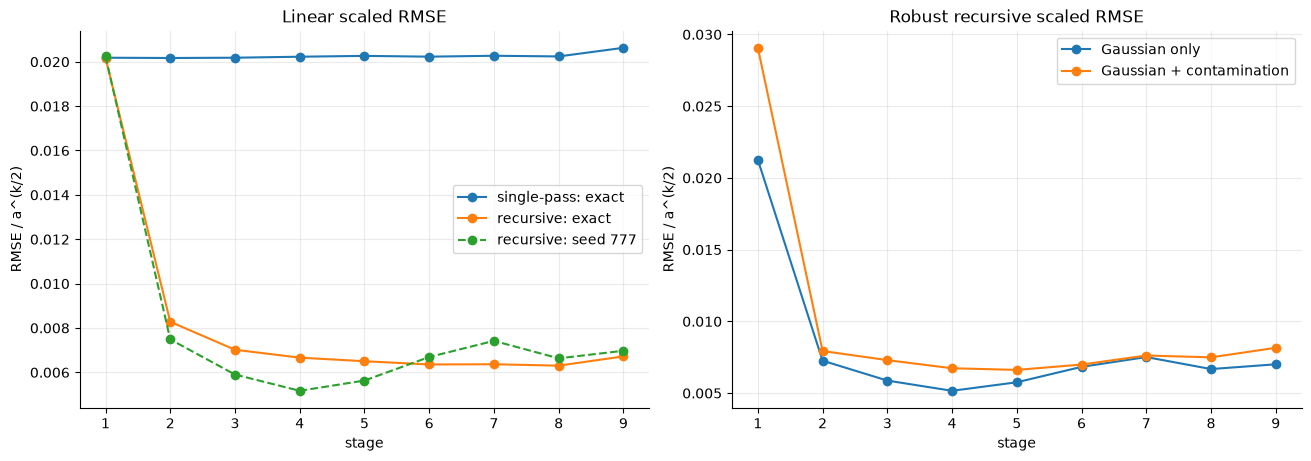

In [3]:
# Compact comparisons and plots
post_first = []
for label, values in [
    ('linear exact', linear_df.set_index('stage')['expected_recursive_scaled_rmse']),
    ('linear realized', linear_df.set_index('stage')['realized_recursive_scaled_rmse']),
]:
    tail = values.loc[2:].to_numpy()
    post_first.append({
        'series': label, 'stage_1': values.loc[1], 'mean_stages_2_9': tail.mean(),
        'stage_1_to_tail_ratio': values.loc[1] / tail.mean(),
        'tail_coefficient_of_variation': tail.std(ddof=1) / tail.mean(),
    })
for case, frame in robust_df.groupby('case', sort=False):
    values = frame.set_index('stage')['recursive_scaled_rmse']
    tail = values.loc[2:].to_numpy()
    post_first.append({
        'series': f'robust: {case}', 'stage_1': values.loc[1], 'mean_stages_2_9': tail.mean(),
        'stage_1_to_tail_ratio': values.loc[1] / tail.mean(),
        'tail_coefficient_of_variation': tail.std(ddof=1) / tail.mean(),
    })
comparison = pd.DataFrame(post_first)
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].plot(linear_df['stage'], linear_df['expected_single_pass_scaled_rmse'], 'o-', label='single-pass: exact')
axes[0].plot(linear_df['stage'], linear_df['expected_recursive_scaled_rmse'], 'o-', label='recursive: exact')
axes[0].plot(linear_df['stage'], linear_df['realized_recursive_scaled_rmse'], 'o--', label='recursive: seed 777')
axes[0].set(title='Linear scaled RMSE', xlabel='stage', ylabel='RMSE / a^(k/2)', xticks=range(1, 10))
axes[0].legend()
for case, frame in robust_df.groupby('case', sort=False):
    axes[1].plot(frame['stage'], frame['recursive_scaled_rmse'], 'o-', label=case)
axes[1].set(title='Robust recursive scaled RMSE', xlabel='stage', ylabel='RMSE / a^(k/2)', xticks=range(1, 10))
axes[1].legend()
plt.show()


## Next steps

The evidence supports treating stage 1 as a separate low-pass boundary component and assessing approximate constancy over stages 2+ (preferably against the exact operator variance), not forcing one constant across all recursive components. For sup errors, use a separate simultaneous-band or Gaussian-process calculation; pointwise $1/(nh)$ scaling alone is insufficient.

For the robust theory, redefine the reference consistently with the paper's population objective. Applying the robust smoother directly to the clean signal is generally not that target because expectation convolves the loss with the noise law. This target mismatch is small in the first-stage Gaussian check here, but it matters for a formal validation.
